# RetailVision AI# - Exploratory Data Analysis (EDA)

## Objective

Analyze the cleaned retail sales data to identify sales trends, customer behavior, and business insights.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(
    r"C:\Users\Saumya S\OneDrive\Desktop\RetailVision-AI\Dataset\cleaned_data.csv",
    parse_dates=["Date"],
    low_memory=False
)

In [4]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Weekday,Quarter
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,NaN,NaN,2015,7,31,Friday,3
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,Friday,3
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,Friday,3
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,NaN,NaN,2015,7,31,Friday,3
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,NaN,NaN,2015,7,31,Friday,3


# Business Question 1

## What are the total sales?

### Objective

Calculate the total sales generated by all stores in the dataset.

In [5]:
total_sales = data["Sales"].sum()

print("Total Sales =", total_sales)

Total Sales = 5873180623


## Observation

The total sales generated by all stores in the dataset are **5,873,180,623**.

This represents the overall revenue generated during the time period covered by the dataset.

# Business Question 2

## What is the average daily sales?

### Objective

Calculate the average sales generated per day across all records.

In [6]:
average_sales = data["Sales"].mean()

print("Average Sales =", round(average_sales,2))

Average Sales = 5773.82


## Observation

The average sales per transaction (record) in the dataset are **5,773.82**.

# Business Question 3

## Which month generates the highest sales?

### Objective

Analyze monthly sales to identify seasonal trends and peak business periods.

In [7]:
monthly_sales = data.groupby("Month")["Sales"].sum()

monthly_sales

Month
1     566728724
2     528734410
3     599831906
4     575895295
5     569248217
6     578112775
7     595059205
8     361791202
9     342570131
10    351878728
11    369498877
12    433831153
Name: Sales, dtype: int64

## Important Note

Comparing total monthly sales can be misleading because the dataset does not contain an equal number of records for every month.

To make a fair comparison, we will calculate the **average sales per month**.

In [8]:
monthly_avg_sales = data.groupby("Month")["Sales"].mean()

monthly_avg_sales

Month
1     5465.395529
2     5645.253150
3     5784.578871
4     5738.866916
5     5489.639973
6     5760.964375
7     6064.915711
8     5693.016554
9     5570.246033
10    5537.037419
11    6008.111821
12    6826.611377
Name: Sales, dtype: float64

## Visualization

The following chart shows the average sales for each month.

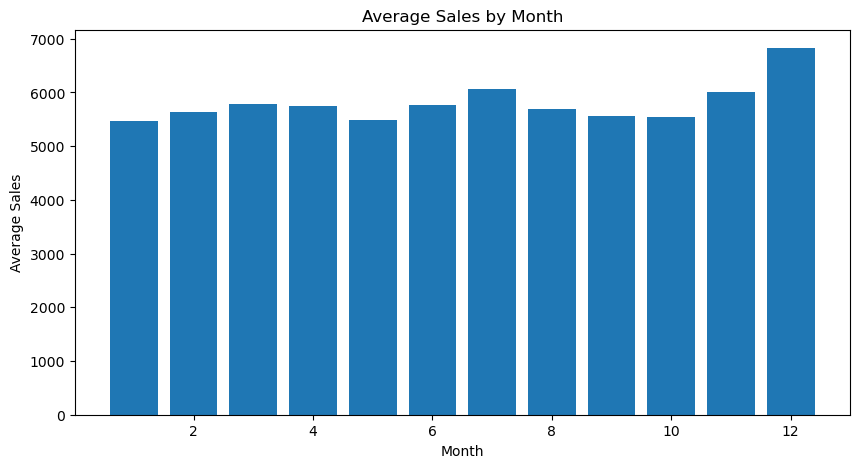

In [9]:
plt.figure(figsize=(10,5))

plt.bar(monthly_avg_sales.index, monthly_avg_sales.values)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

## Observation

The chart shows that December recorded the highest average sales, followed by July and November.

The first half of the year generally shows stable sales, while the festive season months perform better.

# Business Question 4

## Do promotional campaigns increase sales?

### Objective

Compare the average sales on days with promotions and days without promotions to evaluate the effectiveness of promotional campaigns.

In [10]:
promo_sales = data.groupby("Promo")["Sales"].mean()

promo_sales

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

## Observation

The average sales on days **without a promotion** were **4,406.05**.

The average sales on days **with a promotion** were **7,991.15**.

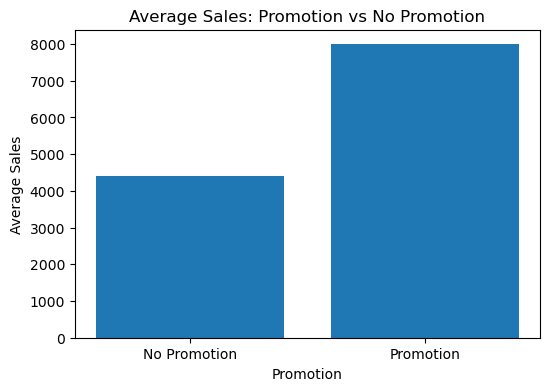

In [11]:
plt.figure(figsize=(6,4))

plt.bar(["No Promotion", "Promotion"], promo_sales.values)

plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.show()

# Business Question 5

## Which weekday generates the highest average sales?

### Objective

Analyze the average sales for each weekday to identify the best-performing day of the week.

In [12]:
weekday_sales=data.groupby("Weekday")["Sales"].mean()
weekday_sales

Weekday
Friday       6723.274305
Monday       7809.044510
Saturday     5847.562599
Sunday        204.183189
Thursday     6247.575913
Tuesday      7005.244467
Wednesday    6555.884138
Name: Sales, dtype: float64

## Observation

- Monday recorded the highest average sales (**7,809.04**).
- Tuesday and Friday also showed strong sales performance.
- Sunday recorded the lowest average sales (**204.18**), mainly because most stores remain closed on Sundays.

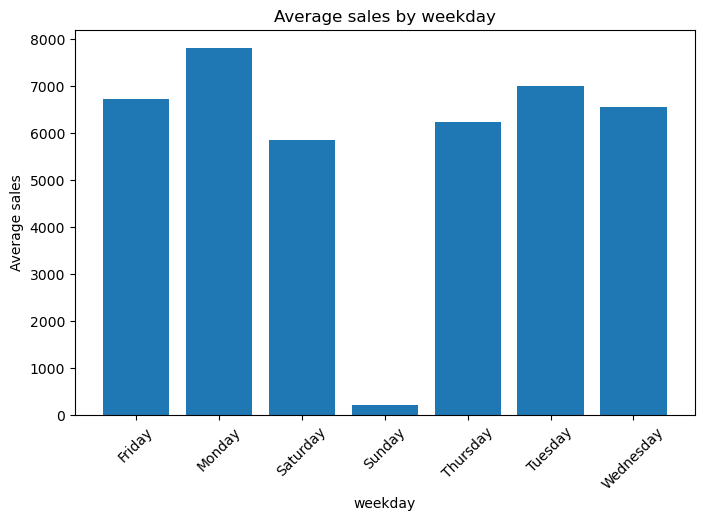

In [13]:
plt.figure(figsize=(8,5))
plt.bar(weekday_sales.index,weekday_sales.values)
plt.title("Average sales by weekday")
plt.xlabel("weekday")
plt.ylabel("Average sales")
plt.xticks(rotation=45)
plt.show()

# Business Question 6

## Which store type generates the highest average sales?

### Objective

Compare the average sales across different store types to identify the best-performing store category.

In [16]:
storetype_sales = data.groupby("StoreType")["Sales"].mean()

storetype_sales

StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64

## Observation

- **Store Type B** recorded the highest average sales (**10,058.84**).
- Store Types A, C, and D have similar average sales, ranging between **5,600** and **5,700**.

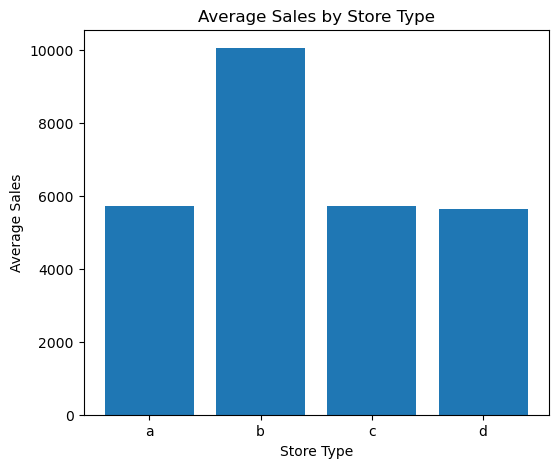

In [17]:
plt.figure(figsize=(6,5))

plt.bar(storetype_sales.index, storetype_sales.values)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()

# Business Question 7

## Which stores generate the highest total sales?

### Objective

Identify the top 10 stores based on total sales.

In [18]:
top10_stores = data.groupby("Store")["Sales"].sum().sort_values(ascending=False).head(10)

top10_stores

Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
513     14252406
788     14082141
733     14067158
383     13489879
756     12911782
Name: Sales, dtype: int64

## Observation

The analysis identified the top 10 stores based on total sales.

- Store **262** generated the highest total sales (**19,516,842**).
- Store **817** ranked second (**17,057,867**).
- Store **562** ranked third (**16,927,322**).

These stores consistently outperformed the others in terms of revenue.

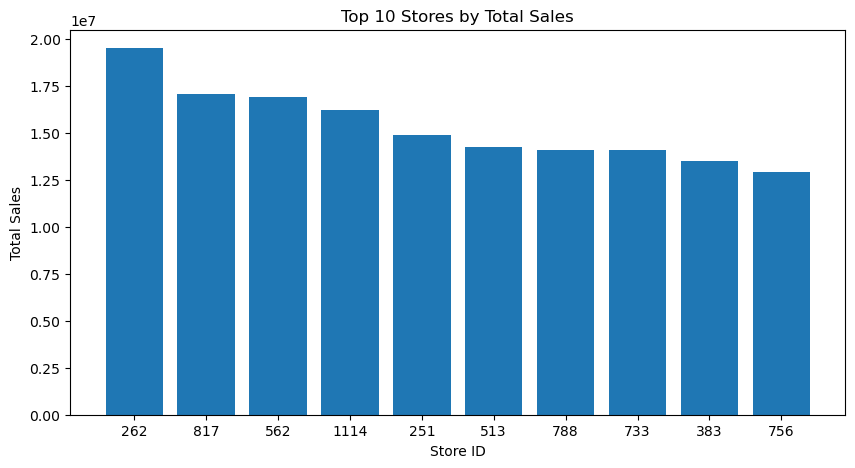

In [19]:
plt.figure(figsize=(10,5))

plt.bar(top10_stores.index.astype(str), top10_stores.values)

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")

plt.show()

# Business Question 8

## Which stores generate the lowest total sales?

### Objective

Identify the bottom 10 stores based on total sales to understand which stores require business attention.

In [20]:
bottom10_stores = data.groupby("Store")["Sales"].sum().sort_values().head(10)

bottom10_stores

Store
307    2114322
543    2179287
198    2268273
208    2302052
263    2306075
841    2318635
879    2340576
254    2341661
186    2353548
972    2402627
Name: Sales, dtype: int64

## Observation

The analysis identified the bottom 10 stores based on total sales.

- Store **307** recorded the lowest total sales (**2,114,322**).
- Store **543** recorded the second-lowest sales (**2,179,287**).
- Store **198** recorded the third-lowest sales (**2,268,273**).

These stores generated significantly lower revenue compared to the top-performing stores.

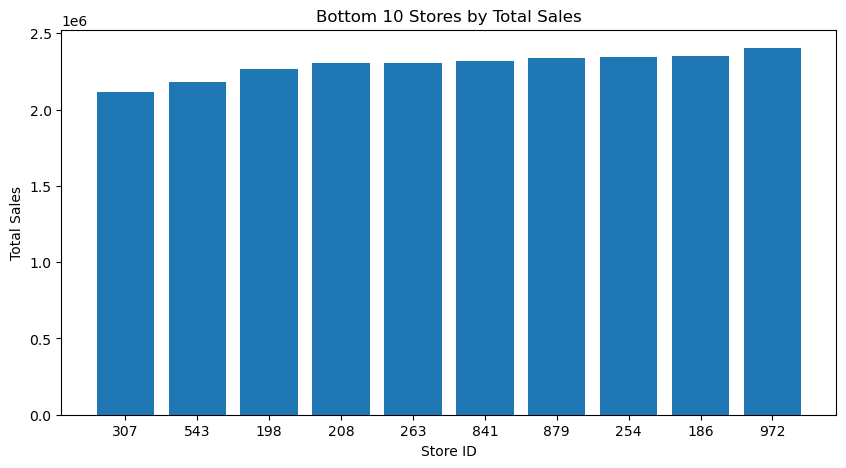

In [21]:
plt.figure(figsize=(10,5))

plt.bar(bottom10_stores.index.astype(str), bottom10_stores.values)

plt.title("Bottom 10 Stores by Total Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")

plt.show()

# Business Question 9

## What is the total number of customers?

### Objective

Calculate the total number of customers who visited the stores.

In [22]:
total_customers = data["Customers"].sum()

print("Total Customers =", total_customers)

Total Customers = 644041755


## Observation

A total of **644,041,755** customers visited the stores during the period covered by the dataset.

# Business Question 10

## What is the average number of customers?

### Objective

Calculate the average number of customers per record.

In [23]:
average_customers = data["Customers"].mean()

print("Average Customers =", round(average_customers,2))

Average Customers = 633.15


## Observation

The average number of customers per record is **633.15**.

# Business Question 11

## Which month has the highest average number of customers?

### Objective

Analyze the average number of customers visiting stores in each month.

In [25]:
monthly_customers = data.groupby("Month")["Customers"].mean()

monthly_customers

Month
1     601.617172
2     626.715129
3     629.401958
4     630.612945
5     601.991263
6     624.794091
7     656.629781
8     642.496979
9     634.438699
10    631.095987
11    654.147967
12    703.067899
Name: Customers, dtype: float64

## Observation

- **December** recorded the highest average number of customers (**703.07**).
- **July** and **November** also showed high customer traffic.
- **January** recorded the lowest average customer count (**601.62**).

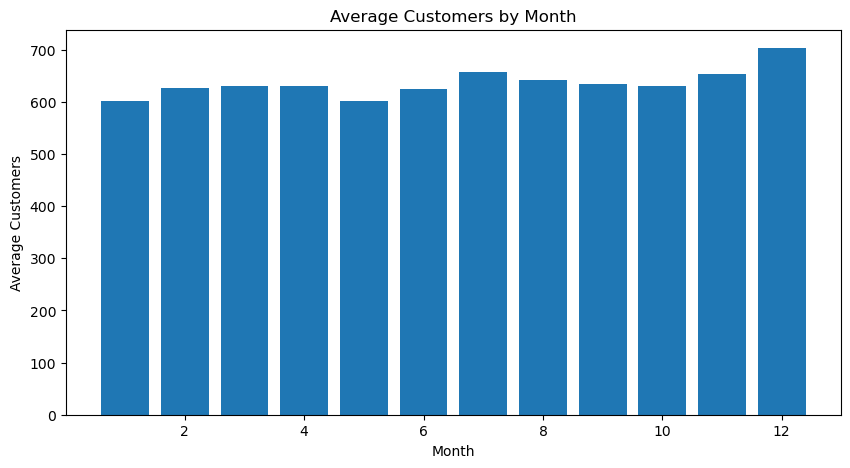

In [26]:
plt.figure(figsize=(10,5))

plt.bar(monthly_customers.index, monthly_customers.values)

plt.title("Average Customers by Month")
plt.xlabel("Month")
plt.ylabel("Average Customers")

plt.show()

# Business Question 12

## Is there a relationship between customers and sales?

### Objective

Measure the relationship between the number of customers and sales using correlation analysis.

In [27]:
correlation = data["Customers"].corr(data["Sales"])

print("Correlation =", round(correlation,2))

Correlation = 0.89


## Observation

The correlation between **Customers** and **Sales** is **0.89**.

This indicates a **strong positive relationship** between the two variables.

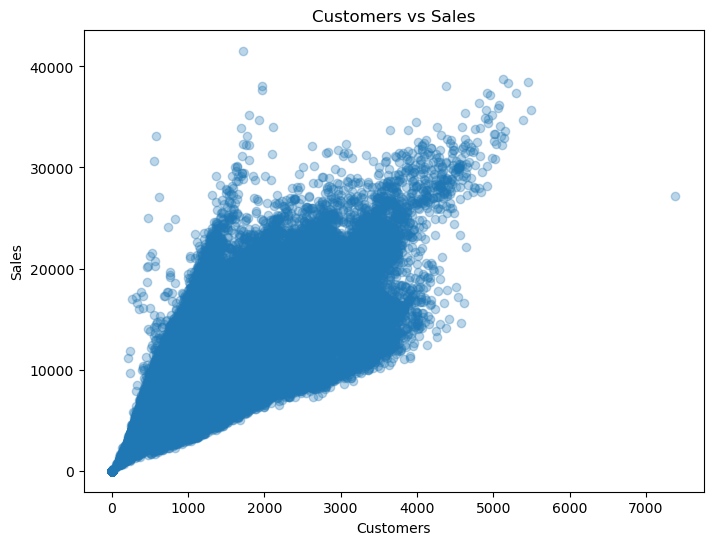

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(data["Customers"], data["Sales"], alpha=0.3)

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

# Business Question 13

## Which assortment type generates the highest average sales?

### Objective

Compare the average sales of different assortment types.

In [29]:
assortment_sales = data.groupby("Assortment")["Sales"].mean()

assortment_sales

Assortment
a    5481.026096
b    8553.931999
c    6058.676567
Name: Sales, dtype: float64

## Observation

- **Assortment Type B** recorded the highest average sales (**8,553.93**).
- **Assortment Type C** recorded an average sales of **6,058.68**.
- **Assortment Type A** recorded the lowest average sales (**5,481.03**).

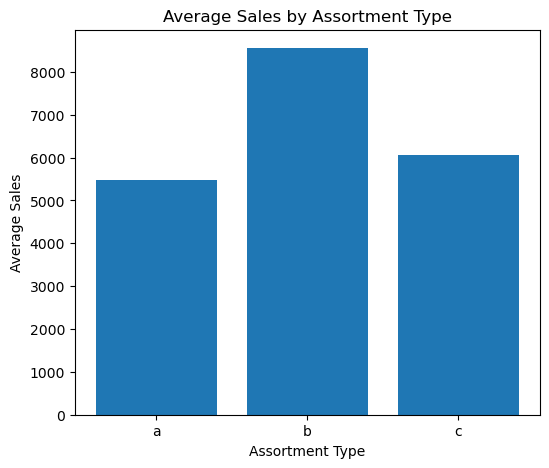

In [30]:
plt.figure(figsize=(6,5))

plt.bar(assortment_sales.index, assortment_sales.values)

plt.title("Average Sales by Assortment Type")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")

plt.show()

# Business Question 14

## Does competition distance affect sales?

### Objective

Analyze the relationship between competition distance and sales.

In [31]:
competition_corr = data["CompetitionDistance"].corr(data["Sales"])

print("Correlation =", round(competition_corr,2))

Correlation = -0.02


## Observation

The correlation between **Competition Distance** and **Sales** is **-0.02**.

This indicates **almost no relationship** between the distance to the nearest competitor and store sales.

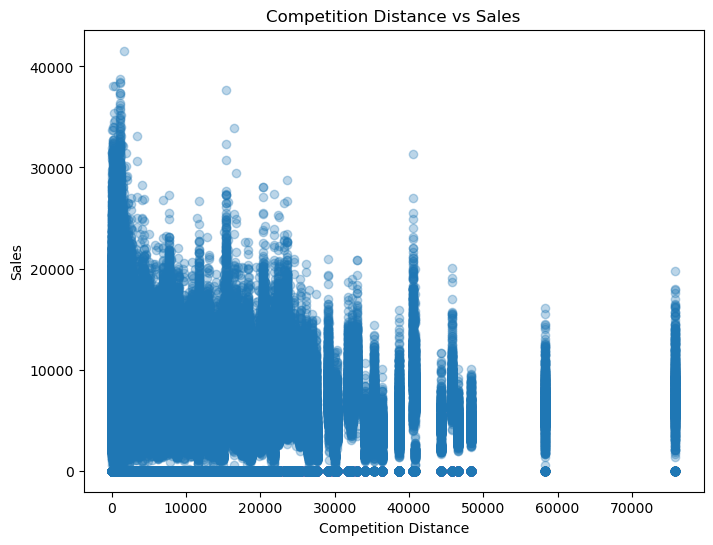

# Business Question 15

## Do open stores generate higher sales than closed stores?

### Objective

Compare average sales of open and closed stores.

In [33]:
open_sales = data.groupby("Open")["Sales"].mean()

open_sales

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

## Observation

- Open stores recorded an average sales of **6,955.51**.
- Closed stores recorded **0** sales.

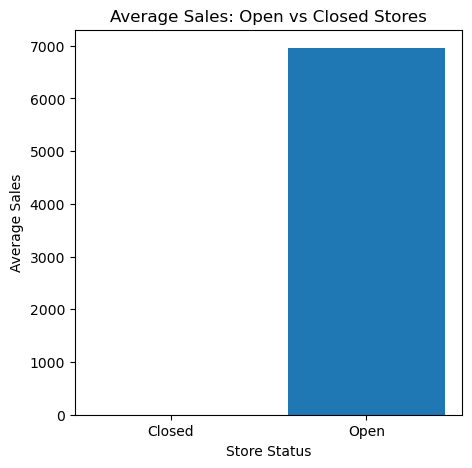

In [34]:
plt.figure(figsize=(5,5))

plt.bar(["Closed","Open"], open_sales.values)

plt.title("Average Sales: Open vs Closed Stores")
plt.xlabel("Store Status")
plt.ylabel("Average Sales")

plt.show()

# Business Question 16

## Do school holidays affect sales?

### Objective

Compare average sales during school holidays and non-school holidays.

In [35]:
school_sales = data.groupby("SchoolHoliday")["Sales"].mean()

school_sales

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

## Observation

- During **School Holidays**, the average sales were **6,476.52**.
- During **Non-School Holidays**, the average sales were **5,620.98**.

Average sales are higher during school holidays.

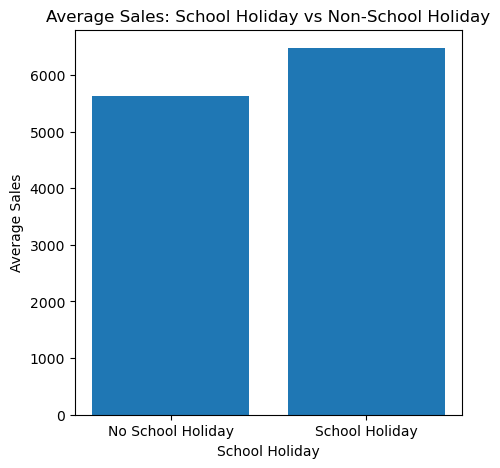

In [36]:
plt.figure(figsize=(5,5))

plt.bar(["No School Holiday","School Holiday"], school_sales.values)

plt.title("Average Sales: School Holiday vs Non-School Holiday")
plt.xlabel("School Holiday")
plt.ylabel("Average Sales")

plt.show()

# Business Question 17

## Which quarter generates the highest average sales?

### Objective

Compare average sales across the four quarters of the year.

In [37]:
quarter_sales = data.groupby("Quarter")["Sales"].mean()

quarter_sales

Quarter
1    5631.292713
2    5661.250306
3    5822.689660
4    6125.178993
Name: Sales, dtype: float64

## Observation

- **Quarter 4 (October–December)** recorded the highest average sales (**6,125.18**).
- Quarter 3 recorded the second-highest average sales (**5,822.69**).
- Quarter 1 recorded the lowest average sales (**5,631.29**).

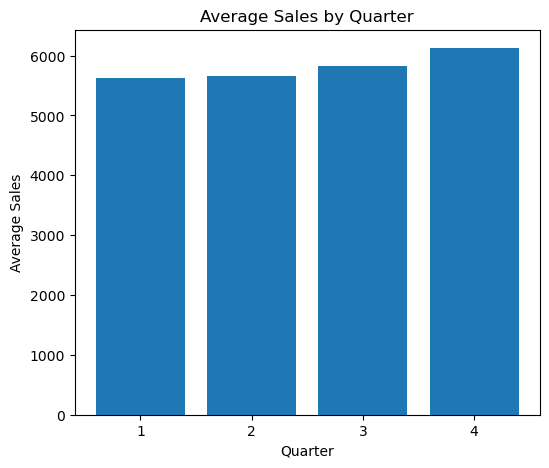

In [39]:
plt.figure(figsize=(6,5))

plt.bar(quarter_sales.index.astype(str), quarter_sales.values)

plt.title("Average Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Sales")

plt.show()

# Business Question 18

## What is the yearly sales trend?

### Objective

Analyze the average sales for each year available in the dataset.

In [40]:
yearly_sales = data.groupby("Year")["Sales"].mean()

yearly_sales

Year
2013    5658.533675
2014    5833.290704
2015    5878.245380
Name: Sales, dtype: float64

## Observation

- **2013** recorded an average sales of **5,658.53**.
- **2014** recorded an average sales of **5,833.29**.
- **2015** recorded the highest average sales of **5,878.25**.

The average sales increased every year.

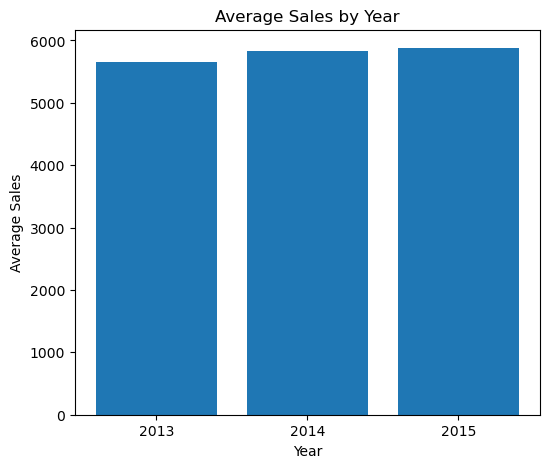

In [41]:
plt.figure(figsize=(6,5))

plt.bar(yearly_sales.index.astype(str), yearly_sales.values)

plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")

plt.show()

# Business Question 19

## Which dates recorded the highest total sales?

### Objective

Identify the top 10 dates with the highest total sales.

In [42]:
top_sales_days = data.groupby("Date")["Sales"].sum().sort_values(ascending=False).head(10)

top_sales_days

Date
2013-12-16    15623548
2013-12-23    14350056
2014-06-30    13308602
2013-12-17    13053993
2013-12-02    12972440
2015-03-30    12371453
2013-12-20    12334496
2013-12-18    12189674
2014-12-15    12133381
2014-03-31    12062933
Name: Sales, dtype: int64

## Observation

The highest sales were recorded on **16 December 2013**, with total sales of **15,623,548**.

Most of the top 10 sales days occurred during **December**, indicating a strong seasonal sales trend.

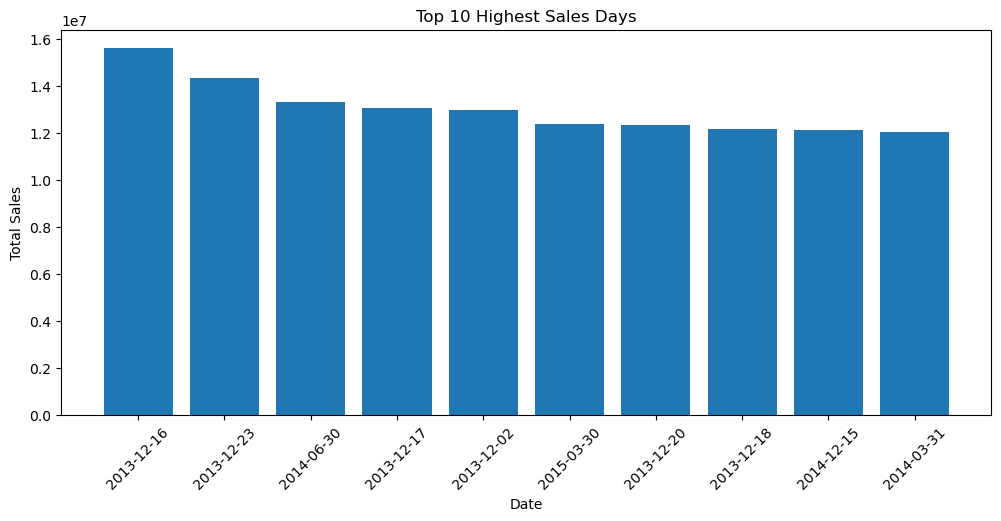

In [43]:
plt.figure(figsize=(12,5))

plt.bar(top_sales_days.index.astype(str), top_sales_days.values)

plt.title("Top 10 Highest Sales Days")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

# Business Question 20

# Executive Summary

## Project Objective

The objective of this project was to analyze retail sales data, identify business trends, understand customer behavior, and provide data-driven recommendations to improve business performance.

---

## Key Findings

- Total Sales: **5.87 Billion**
- Average Sales: **5,773.82**
- Total Customers: **644 Million**
- Average Customers: **633.15**
- December recorded the highest average sales.
- Quarter 4 was the best-performing quarter.
- Monday generated the highest average sales.
- Promotions increased average sales significantly.
- Store Type B achieved the highest average sales.
- Assortment Type B generated the highest revenue.
- Customer traffic has a very strong positive correlation with sales (**0.89**).
- Competition distance had almost no impact on sales (**-0.02**).

---

## Business Recommendations

- Increase promotional campaigns during festive seasons.
- Expand successful strategies used by Store Type B.
- Increase inventory and staffing during Quarter 4.
- Focus on increasing customer traffic through marketing and loyalty programs.
- Improve the performance of low-performing stores using insights from top-performing stores.

---

## Conclusion

The analysis demonstrates that promotions, customer traffic, store type, and seasonal trends are the primary drivers of sales performance.

The insights generated from this project can support management in making data-driven decisions related to marketing, inventory planning, staffing, and business growth.

The cleaned dataset is now ready for SQL analysis, Power BI dashboard development, and Machine Learning sales forecasting.